# Plots for thesis and random checks

In [1]:
import os
import json
import math
import yaml
import numpy as np
import matplotlib.pyplot as plt

# switch to emu directory
os.chdir('/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu')

import predict
import load_data
import plot_prediction

# switch to the main directory
os.chdir('/home/s2561233/Documents/lss/ridges/ridges_toolkit/')

PARAMETER_ORDER = [
    'bary_Mc',
    'bary_nu',
    'H0',
    'Omega_b',
    'Omega_m',
    'ns',
    'sigma8',
    'w0',
]

I0000 00:00:1790859599.428658  345258 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790859599.429002  345258 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790859599.462052  345258 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790859600.426102  345258 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

### Prediciton vs simulated signal (example)

In [2]:
# get radial bins, mean and stdev from metadata
with open('emu/data/metadata.json', 'r') as f:
    metadata = json.load(f)

bin_pairs = metadata['bin_pairs']
sep_bin_center = metadata['sep_bin_center']
nperm = 1000
sigma_e = 0.26

# choose two simulations indices to plot against prediction
idx1 = 0
idx2 = 47

E0000 00:00:1790859600.922416  345258 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu/plot_prediction.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()
/tmp/ipykernel_345258/81970751.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


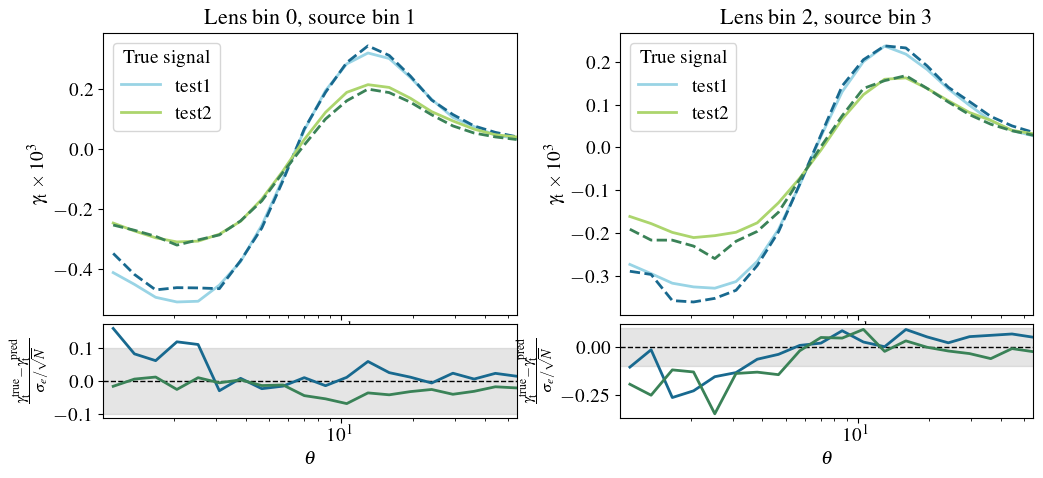

In [3]:
# big plot with multiple subplots, each one having a different bin pair (lens, source)
plot_pair = [(0,1), (2,3)]

nrows = 1
ncols = math.ceil(len(plot_pair) / nrows)
fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
outer_grid = fig.add_gridspec(nrows, ncols, hspace=0.35, wspace=0.25)

for panel_idx, (l, s) in enumerate(plot_pair):
    row = panel_idx // ncols
    col = panel_idx % ncols
    inner_grid = outer_grid[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax0 = fig.add_subplot(inner_grid[0])
    ax1 = fig.add_subplot(inner_grid[1], sharex=ax0)

    model_path = f'emu/models/lens{l}_source{s}.keras'
    X_test, Y_test, shape_noise = load_data.load_dataset(l, s)
    params_dict = {par: X_test[:, i] for i, par in enumerate(PARAMETER_ORDER)}
    prediction = predict.make_prediction(params_dict, l, s, model_path)

    plot_prediction.plot_prediction_shapenoise(
        xarr=sep_bin_center,
        predicted_signal=prediction,
        true_signal=Y_test,
        shape_noise=shape_noise,
        l=l,
        s=s,
        idx1=idx1,
        idx2=idx2,
        xlabel=r'$\theta$',
        ylabel=r'$\gamma_{\rm t}\, \times10^3$',
        ylabel_residuals=r'$\frac{\gamma_{\rm t}^{\rm true} - \gamma_{\rm t}^{\rm pred}}{\sigma_e/\sqrt{N}}$',
        legend=['test1', 'test2'],
        title=f'Lens bin {l}, source bin {s}',
        fontsize=14,
        ax0=ax0,
        ax1=ax1,
        save=False,
    )

for panel_idx in range(len(plot_pair), nrows * ncols):
    row = panel_idx // ncols
    col = panel_idx % ncols
    fig.add_subplot(outer_grid[row, col]).axis('off')

fig.tight_layout()
fig.savefig('emu/figs/true_predict_thesis.pdf')
# plt.show()

### Prediction vs simulated: Average over fiducial cosmology to get rid of realization error

In [4]:
# read fiducials from yaml file 
fid_file = 'emu/notebooks/fiducials_cosmogrid.yaml'
with open(fid_file, 'r') as f:
    fiducials = yaml.safe_load(f)
print(fiducials)

{'Omega_m': 0.26, 'bary_Mc': 13.82, 'bary_nu': 0.0, 'sigma8': 0.84, 'w0': -1.0, 'ns': 0.9649, 'Omega_b': 0.0493, 'H0': 67.3, 'S8': 0.7819974424510607}


In [5]:
folder = 'fiducial-shear-noisy/fiducial/noisy-shear/'

def read_data(loc, nperm, bin_lens, bin_source):
    file = loc + f'perm_{nperm}_shear_lens{bin_lens}_source{bin_source}.txt'
    # print(file)
    sep_bin_center, _, g_plus, g_cross, counts, _ = np.genfromtxt(file, unpack=True)
    return sep_bin_center, g_plus, g_cross, counts

In [6]:
signal = np.zeros((nperm, len(bin_pairs), len(sep_bin_center)))
shot_noise = np.zeros((nperm, len(bin_pairs), len(sep_bin_center)))

for i, (l, s) in enumerate(bin_pairs):
    for p in range(nperm):
        # make per number foru digits (eg. 1 --> 0001)
        p_str = str(p).zfill(4)
        sep_bin_center, g_plus, g_cross, counts = read_data(folder, p_str, l, s)
        signal[p, i, :] = g_plus
        shot_noise[p, i, :] = sigma_e / np.sqrt(counts) 

# compute signal average per each bin pair
mean_fiducial_signal = np.mean(signal, axis=0)

In [7]:
# # std dev of fiducial permutations
# std_fiducial_signal = np.std(signal, axis=0) / np.sqrt(nperm)
# # shape noise squared sum
# sigma_noise_sum2 = np.sum(shot_noise**2, axis=0) / nperm**2
# # total uncertainty (as in covariance => both shape and realisation error)
# sigma_mean = np.sqrt(std_fiducial_signal**2 + sigma_noise_sum2)

/home/s2561233/Documents/lss/ridges/ridges_toolkit/emu/plot_prediction.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  f.tight_layout()


/tmp/ipykernel_345258/3341073691.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


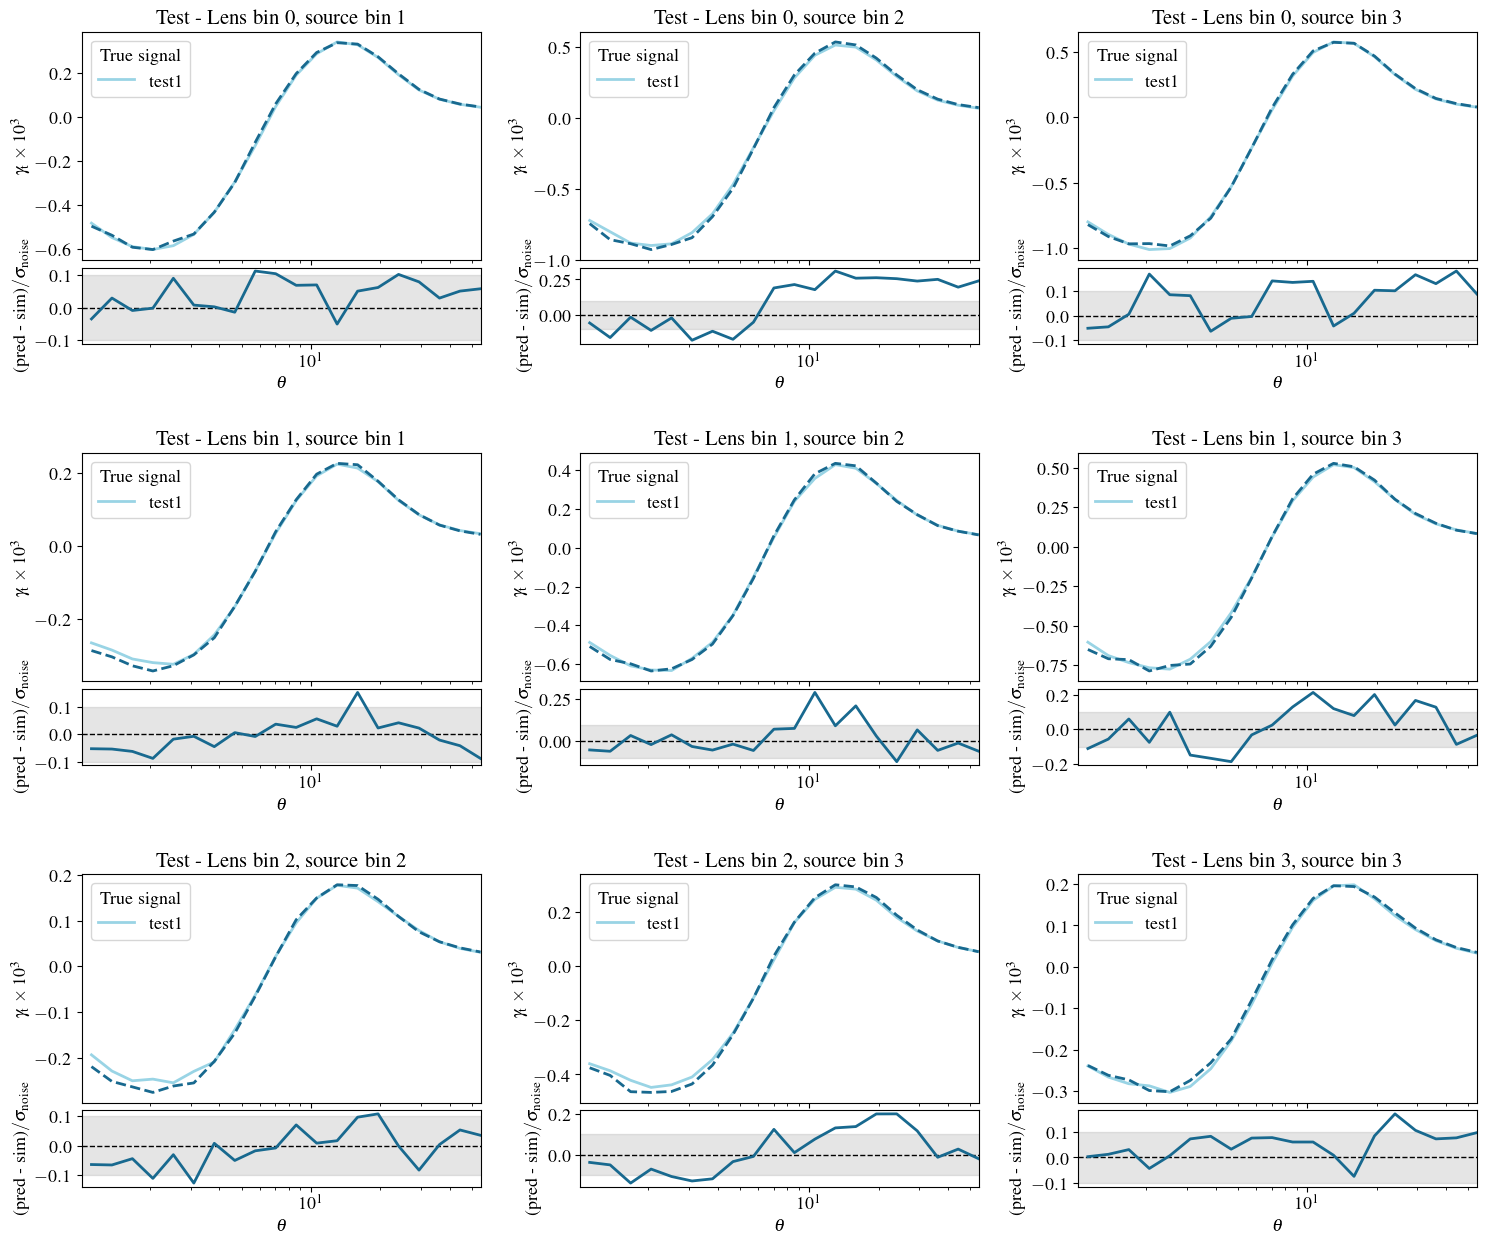

In [8]:
# big plot with multiple subplots, each one having a different bin pair (lens, source)
all_pairs = metadata["bin_pairs"]
ncols = 3
nrows = math.ceil(len(all_pairs) / ncols)
fig = plt.figure(figsize=(6 * ncols, 5 * nrows))
outer_grid = fig.add_gridspec(nrows, ncols, hspace=0.35, wspace=0.25)

for panel_idx, (l, s) in enumerate(all_pairs):
    row = panel_idx // ncols
    col = panel_idx % ncols
    inner_grid = outer_grid[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax0 = fig.add_subplot(inner_grid[0])
    ax1 = fig.add_subplot(inner_grid[1], sharex=ax0)

    model_path = f'emu/models/lens{l}_source{s}.keras'
    prediction = predict.make_prediction(fiducials, l, s, model_path)

    plot_prediction.plot_prediction_shapenoise(
        xarr=sep_bin_center,
        predicted_signal=prediction,
        true_signal=[mean_fiducial_signal[panel_idx, :]],
        shape_noise=[shot_noise[panel_idx, :]],
        l=l,
        s=s,
        idx1=idx1,
        xlabel=r'$\theta$',
        ylabel=r'$\gamma_{\rm t}\, \times10^3$',
        ylabel_residuals=r'(pred - sim)$/\sigma_{\rm noise}$',
        legend=['test1', 'test2'],
        title=f'Test - Lens bin {l}, source bin {s}',
        fontsize=13,
        ax0=ax0,
        ax1=ax1,
        save=False,
        savename='all_bins.pdf',
        # noise_true=sigma_mean[panel_idx, :],
    )

# hide any unused panels if the grid is larger than the number of bin pairs
for panel_idx in range(len(all_pairs), nrows * ncols):
    row = panel_idx // ncols
    col = panel_idx % ncols
    fig.add_subplot(outer_grid[row, col]).axis('off')

fig.tight_layout()
plt.show()

In [9]:
lmax = np.array([139, 204, 264, 315])
print('Extended theta: ', 180/lmax*60, 'arcmin')

lmax = np.array([70, 103, 133, 158])
print('Conservative theta: ', 180/lmax*60, 'arcmin')

Extended theta:  [77.69784173 52.94117647 40.90909091 34.28571429] arcmin
Conservative theta:  [154.28571429 104.85436893  81.20300752  68.35443038] arcmin


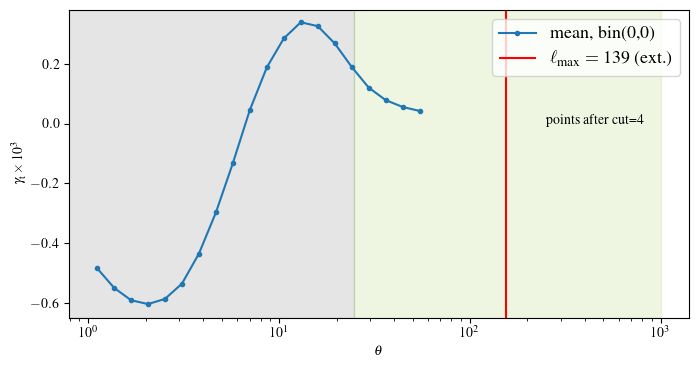

In [10]:
plt.figure(figsize=(8,4))

plt.plot(sep_bin_center, mean_fiducial_signal[0, :]*1e3, '.-', label='mean, bin(0,0)')
plt.axvspan(24.75, 999.0, color='#ACD56D', alpha=0.2)
plt.axvspan(0., 24.75, color='k', alpha=0.1)

plt.vlines(180/lmax[0]*60, -0.7, 0.5, color='r', label=r'$\ell_{\rm max}=139$ (ext.)')
# plt.vlines(np.pi/70*60, -0.7, 0.5, color='r', linestyle='dashed', label=r'$\ell_{\rm max}=70$ (cons.)')

plt.xscale('log')
# plt.xlim(min(sep_bin_center)-0.1, 999)
plt.ylim(-0.65, 0.38)
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\gamma_{\rm t}\times10^3$')
plt.legend(loc='upper right', fontsize=13)
plt.text(2.5e2, 0., 'points after cut=4')
plt.show()

- Green = area considered after cut, DES Y3 (CosmoSIS, matches [DES Y3 Abbott2022](https://arxiv.org/pdf/2105.13549))
- Red = scale cuts considered in [DES-Y3 GGL in harmonic space](https://arxiv.org/pdf/2406.12675)

/tmp/ipykernel_345258/2522381681.py:11: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 999)


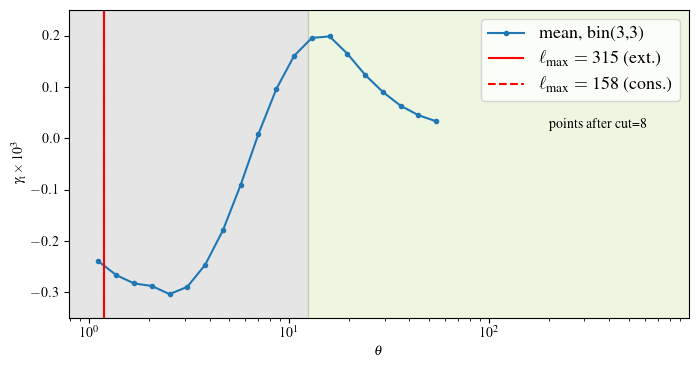

In [11]:
plt.figure(figsize=(8,4))

plt.plot(sep_bin_center, mean_fiducial_signal[-1, :]*1e3, '.-', label='mean, bin(3,3)')
plt.axvspan(12.40438403, 999.0, color='#ACD56D', alpha=0.2)
plt.axvspan(0., 12.40438403, color='k', alpha=0.1)
plt.vlines(np.pi/lmax[-1]*60, -0.7, 0.5, color='r', label=r'$\ell_{\rm max}=315$ (ext.)')
plt.vlines(np.pi/158*60, -0.7, 0.5, color='r', linestyle='dashed', label=r'$\ell_{\rm max}=158$ (cons.)')
plt.xscale('log')

# plt.xlim(min(sep_bin_center)-0.1, 999)
plt.xlim(0, 999)
plt.ylim(-0.35, 0.25)
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\gamma_{\rm t}\times10^3$')
plt.legend(loc='upper right', fontsize=13)
plt.text(2e2, 0.02, 'points after cut=8')
plt.show()